# Multivariate accuracy and construction complexity

This notebook separates the three numerical mechanisms:

- ReLU accuracy is controlled by the squaring-network depth $L$.
- Tanh accuracy is controlled by finite-difference steps. Automatic steps use
  a requested tolerance; explicit steps expose truncation and cancellation.
- RePU-2 multiplication is algebraically exact up to floating-point error.

All reported errors are maxima over a fixed random sample, not certified
uniform errors.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from neural_polynomial_emulation import (
    MultivariateBasisEmulator,
    emulator_complexity,
    exact_multivariate_basis,
    multi_index_set,
    relative_frobenius_mismatch,
)

DIMENSION = 2
ORDER = 4
FAMILY = "legendre"
INDEX_SET_TYPE = "total_degree"
NUM_POINTS = 1024
SEED = 13579

RELU_DEPTHS = (4, 8, 12, 16, 20, 24)
TANH_TOLERANCES = (1e-4, 1e-6, 1e-8, 1e-10, 1e-12)
TANH_STEPS = np.geomspace(0.5, 2e-4, 21)

SCALING_DIMENSIONS = (1, 2, 3)
SCALING_ORDERS = (2, 3, 4)
SCALING_INDEX_SETS = ("total_degree", "hyperbolic_cross")
SCALING_NUM_POINTS = 256


## Complexity convention

The size statistics use a modular standard-feedforward embedding of each
scalar multiplier. A depth-$L$ ReLU multiplier has $L$ hidden layers of width
12 for $L\geq1$ (or one width-three layer for $L=0$). Tanh and RePU-2
multipliers have one hidden layer of width six and four, respectively.
`total_parameters` counts every dense weight and bias slot;
`nonzero_parameters` counts the sparse analytic realization. Counts are summed
over multiplier nodes and include modular affine root shifts, final polynomial
scaling, and degree-zero constants. Artificial padding between independent
branches is excluded. `trainable_parameters`
remains zero because these constructions have no fitted weights.

Changing the tanh step or tolerance changes weight magnitudes and numerical
conditioning, but not network size.


In [2]:
rng = np.random.default_rng(SEED)
points = rng.uniform(-0.95, 0.95, size=(NUM_POINTS, DIMENSION))
points_tensor = torch.as_tensor(points, dtype=torch.float64)
indices = multi_index_set(DIMENSION, ORDER, INDEX_SET_TYPE)
exact = exact_multivariate_basis(points, indices, family=FAMILY)


def evaluate(model):
    model = model.to(dtype=torch.float64)
    with torch.no_grad():
        approximate = model(points_tensor).cpu().numpy()
    column_errors = np.max(np.abs(approximate - exact), axis=0)
    return {
        "sample_max_error": float(np.max(column_errors)),
        "median_column_error": float(np.median(column_errors)),
        "relative_frobenius_mismatch": relative_frobenius_mismatch(
            exact, approximate
        ),
        **emulator_complexity(model),
    }


def all_tanh_steps(model):
    steps = []
    for coordinate_basis in model.coordinate_emulators:
        for emulator in coordinate_basis.emulators:
            for level in emulator.tanh_steps(torch.float64):
                steps.extend(level)
    for feature_steps in model.cross_tanh_steps(torch.float64):
        steps.extend(feature_steps)
    return np.asarray(steps, dtype=np.float64)


pd.DataFrame(
    [
        {
            "dimension": DIMENSION,
            "order": ORDER,
            "family": FAMILY,
            "index_set": INDEX_SET_TYPE,
            "n_features": len(indices),
        }
    ]
)


,dimension,order,family,index_set,n_features
0,2,4,legendre,total_degree,15


## ReLU depth sweep


In [3]:
relu_rows = []
for depth in RELU_DEPTHS:
    model = MultivariateBasisEmulator(
        indices,
        family=FAMILY,
        product="relu",
        num_layers=depth,
    )
    relu_rows.append({"depth": depth, **evaluate(model)})
relu_table = pd.DataFrame(relu_rows)
relu_table


,depth,sample_max_error,median_column_error,relative_frobenius_mismatch,product_nodes,relu_product_nodes,tanh_product_nodes,repu2_product_nodes,activation_units_per_sample,total_parameters,nonzero_parameters,trainable_parameters,buffer_scalars
0,4,6.105054e+00,1.454225e-01,1.536321e+00,18,18,0,0,864,9366,3070,0,60
1,8,2.455726e-02,4.502425e-04,4.725353e-03,18,18,0,0,1728,20598,6310,0,60
2,12,1.043991e-04,1.925258e-06,1.771555e-05,18,18,0,0,2592,31830,9550,0,60
3,16,4.081148e-07,8.290987e-09,6.961212e-08,18,18,0,0,3456,43062,12790,0,60
4,20,1.578791e-09,2.700529e-11,2.783222e-10,18,18,0,0,4320,54294,16030,0,60
5,24,5.976386e-12,1.647571e-13,1.048841e-12,18,18,0,0,5184,65526,19270,0,60


## Automatic tanh-tolerance sweep


In [4]:
tanh_tolerance_rows = []
for tolerance in TANH_TOLERANCES:
    model = MultivariateBasisEmulator(
        indices,
        family=FAMILY,
        product="tanh",
        tanh_tolerance=tolerance,
    )
    steps = all_tanh_steps(model)
    tanh_tolerance_rows.append({
        "tolerance": tolerance,
        "minimum_step": float(np.min(steps)),
        "maximum_step": float(np.max(steps)),
        **evaluate(model),
    })
tanh_tolerance_table = pd.DataFrame(tanh_tolerance_rows)
tanh_tolerance_table


,tolerance,minimum_step,maximum_step,sample_max_error,median_column_error,relative_frobenius_mismatch,product_nodes,relu_product_nodes,tanh_product_nodes,repu2_product_nodes,activation_units_per_sample,total_parameters,nonzero_parameters,trainable_parameters,buffer_scalars
0,1.000000e-04,0.045122,0.149535,6.516160e-05,2.651285e-06,4.893368e-06,18,0,18,0,108,510,406,0,60
1,1.000000e-06,0.014269,0.047287,6.534390e-07,2.653521e-08,4.902342e-08,18,0,18,0,108,510,406,0,60
2,1.000000e-08,0.004555,0.014953,6.533619e-09,3.705514e-10,4.919552e-10,18,0,18,0,108,510,406,0,60
3,1.000000e-10,0.003096,0.004729,5.159109e-10,2.894470e-10,1.001422e-10,18,0,18,0,108,510,406,0,60
4,1.000000e-12,0.002955,0.004555,5.159109e-10,3.219702e-10,1.047251e-10,18,0,18,0,108,510,406,0,60


The tolerance is allocated across product nodes. Consequently the effective
steps differ by node; the table reports their range.


## Explicit tanh-step sweep


In [5]:
tanh_step_rows = []
for step in TANH_STEPS:
    model = MultivariateBasisEmulator(
        indices,
        family=FAMILY,
        product="tanh",
        tanh_step=float(step),
    )
    tanh_step_rows.append({
        "step": float(step),
        "inverse_step_squared": float(step**-2),
        **evaluate(model),
    })
tanh_step_table = pd.DataFrame(tanh_step_rows)
tanh_step_table


,step,inverse_step_squared,sample_max_error,median_column_error,relative_frobenius_mismatch,product_nodes,relu_product_nodes,tanh_product_nodes,repu2_product_nodes,activation_units_per_sample,total_parameters,nonzero_parameters,trainable_parameters,buffer_scalars
0,0.500000,4.000000e+00,1.110313e-02,3.951925e-03,1.026834e-03,18,0,18,0,108,510,406,0,60
1,0.338122,8.746897e+00,2.357181e-03,8.352943e-04,2.170485e-04,18,0,18,0,108,510,406,0,60
2,0.228653,1.912705e+01,4.959753e-04,1.754532e-04,4.559855e-05,18,0,18,0,108,510,406,0,60
3,0.154625,4.182558e+01,1.039955e-04,3.676235e-05,9.555184e-06,18,0,18,0,108,510,406,0,60
4,0.104564,9.146101e+01,2.177376e-05,7.694594e-06,2.000070e-06,18,0,18,0,108,510,406,0,60
5,0.070711,2.000000e+02,4.555900e-06,1.609775e-06,4.184428e-07,18,0,18,0,108,510,406,0,60
6,0.047818,4.373448e+02,9.529936e-07,3.367080e-07,8.752448e-08,18,0,18,0,108,510,406,0,60
7,0.032336,9.563525e+02,1.993198e-07,7.042916e-08,1.830543e-08,18,0,18,0,108,510,406,0,60
8,0.021867,2.091279e+03,4.167037e-08,1.471671e-08,3.828317e-09,18,0,18,0,108,510,406,0,60
9,0.014788,4.573051e+03,8.742516e-09,3.067389e-09,8.007223e-10,18,0,18,0,108,510,406,0,60


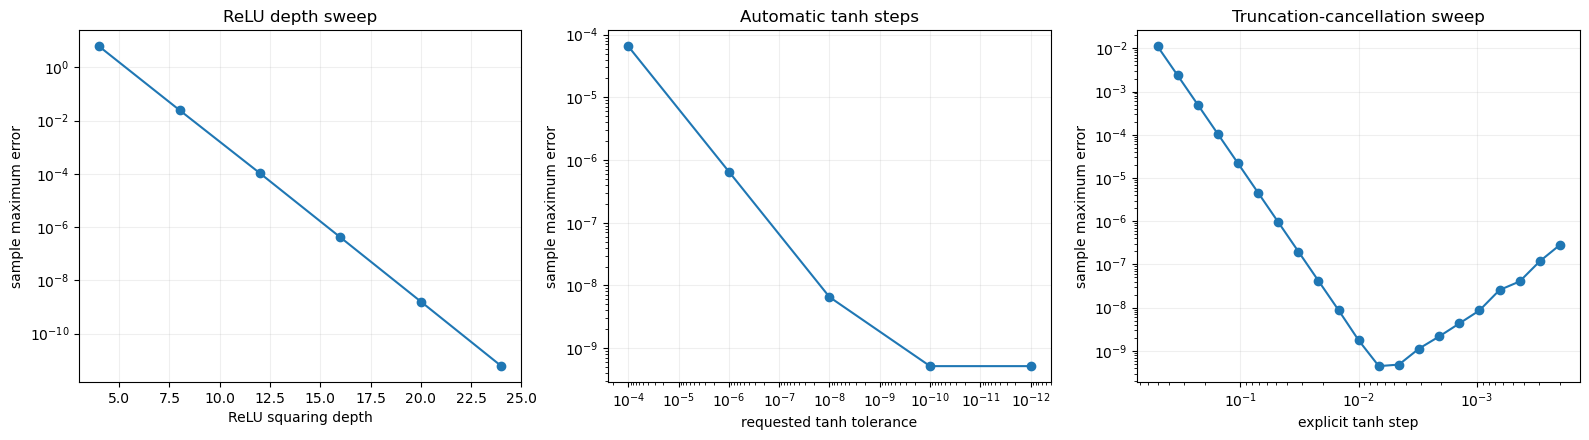

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].semilogy(
    relu_table["depth"], relu_table["sample_max_error"], marker="o"
)
axes[0].set(
    xlabel="ReLU squaring depth",
    ylabel="sample maximum error",
    title="ReLU depth sweep",
)

axes[1].loglog(
    tanh_tolerance_table["tolerance"],
    tanh_tolerance_table["sample_max_error"],
    marker="o",
)
axes[1].invert_xaxis()
axes[1].set(
    xlabel="requested tanh tolerance",
    ylabel="sample maximum error",
    title="Automatic tanh steps",
)

axes[2].loglog(
    tanh_step_table["step"],
    tanh_step_table["sample_max_error"],
    marker="o",
)
axes[2].invert_xaxis()
axes[2].set(
    xlabel="explicit tanh step",
    ylabel="sample maximum error",
    title="Truncation-cancellation sweep",
)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## Error versus represented construction size


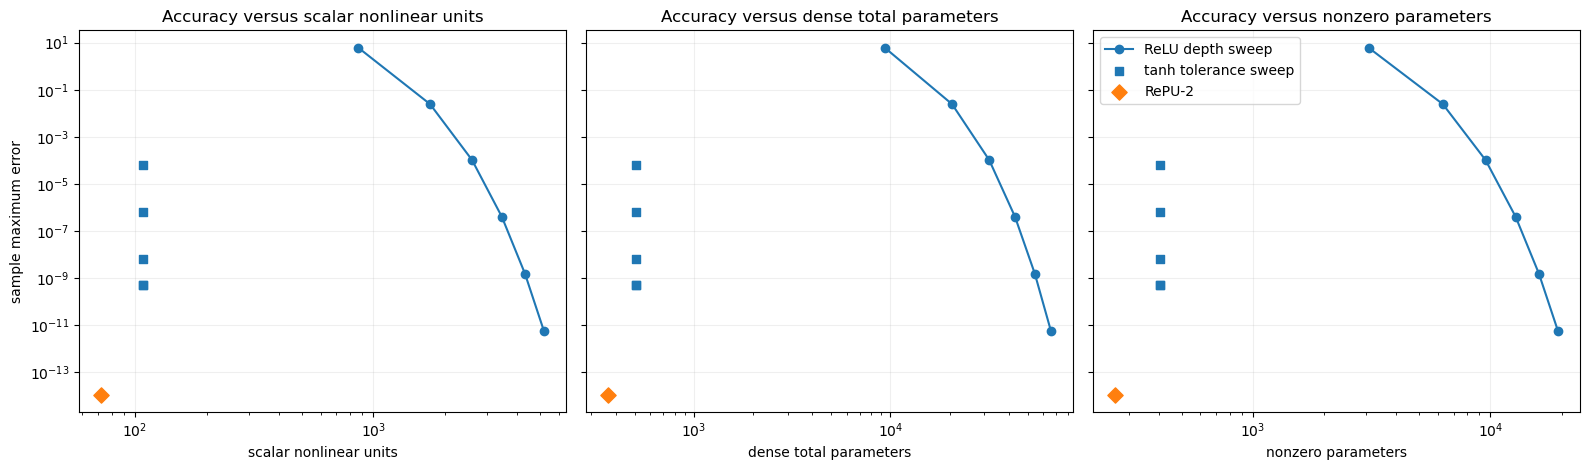

In [7]:
repu_model = MultivariateBasisEmulator(
    indices, family=FAMILY, product="repu2"
)
repu_row = evaluate(repu_model)

size_metrics = (
    ("activation_units_per_sample", "scalar nonlinear units"),
    ("total_parameters", "dense total parameters"),
    ("nonzero_parameters", "nonzero parameters"),
)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, (metric, label) in zip(axes, size_metrics):
    ax.loglog(
        relu_table[metric],
        relu_table["sample_max_error"],
        marker="o",
        label="ReLU depth sweep",
    )
    ax.scatter(
        tanh_tolerance_table[metric],
        tanh_tolerance_table["sample_max_error"],
        marker="s",
        label="tanh tolerance sweep",
    )
    ax.scatter(
        [repu_row[metric]],
        [repu_row["sample_max_error"]],
        marker="D",
        s=60,
        label="RePU-2",
    )
    ax.set(xlabel=label, title=f"Accuracy versus {label}")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("sample maximum error")
axes[-1].legend(loc="best")
fig.tight_layout()
plt.show()


The tanh points share one horizontal coordinate because tolerance changes its
weights and effective steps, not its number of units. The explicit-step table
records the corresponding inverse-square weight-growth proxy.


## Dimension and order scaling


In [8]:
scaling_rng = np.random.default_rng(SEED + 1)
scaling_rows = []
for dimension in SCALING_DIMENSIONS:
    scaling_points = scaling_rng.uniform(
        -0.95, 0.95, size=(SCALING_NUM_POINTS, dimension)
    )
    scaling_tensor = torch.as_tensor(scaling_points, dtype=torch.float64)
    for order in SCALING_ORDERS:
        for index_set_type in SCALING_INDEX_SETS:
            scaling_indices = multi_index_set(dimension, order, index_set_type)
            scaling_exact = exact_multivariate_basis(
                scaling_points, scaling_indices, family=FAMILY
            )
            for product in ("relu", "tanh", "repu2"):
                model = MultivariateBasisEmulator(
                    scaling_indices,
                    family=FAMILY,
                    product=product,
                    num_layers=12,
                    tanh_tolerance=1e-4,
                ).to(dtype=torch.float64)
                with torch.no_grad():
                    approximate = model(scaling_tensor).cpu().numpy()
                complexity = emulator_complexity(model)
                scaling_rows.append({
                    "dimension": dimension,
                    "order": order,
                    "index_set": index_set_type,
                    "product": product,
                    "n_features": len(scaling_indices),
                    "sample_max_error": float(
                        np.max(np.abs(approximate - scaling_exact))
                    ),
                    **complexity,
                })
scaling_table = pd.DataFrame(scaling_rows)
scaling_table


,dimension,order,index_set,product,n_features,sample_max_error,product_nodes,relu_product_nodes,tanh_product_nodes,repu2_product_nodes,activation_units_per_sample,total_parameters,nonzero_parameters,trainable_parameters,buffer_scalars
0,1,2,total_degree,relu,3,9.363063e-07,1,1,0,0,144,1777,536,0,9
1,1,2,total_degree,tanh,3,1.439113e-06,1,0,1,0,6,37,28,0,9
2,1,2,total_degree,repu2,3,1.332268e-15,1,0,0,1,4,29,20,0,9
3,1,2,hyperbolic_cross,relu,3,9.363063e-07,1,1,0,0,144,1777,536,0,9
4,1,2,hyperbolic_cross,tanh,3,1.439113e-06,1,0,1,0,6,37,28,0,9
5,1,2,hyperbolic_cross,repu2,3,1.332268e-15,1,0,0,1,4,29,20,0,9
6,1,3,total_degree,relu,4,1.161922e-05,3,3,0,0,432,5315,1598,0,14
7,1,3,total_degree,tanh,4,2.414304e-06,3,0,3,0,18,95,74,0,14
8,1,3,total_degree,repu2,4,2.331468e-15,3,0,0,3,12,71,50,0,14
9,1,3,hyperbolic_cross,relu,4,1.161922e-05,3,3,0,0,432,5315,1598,0,14


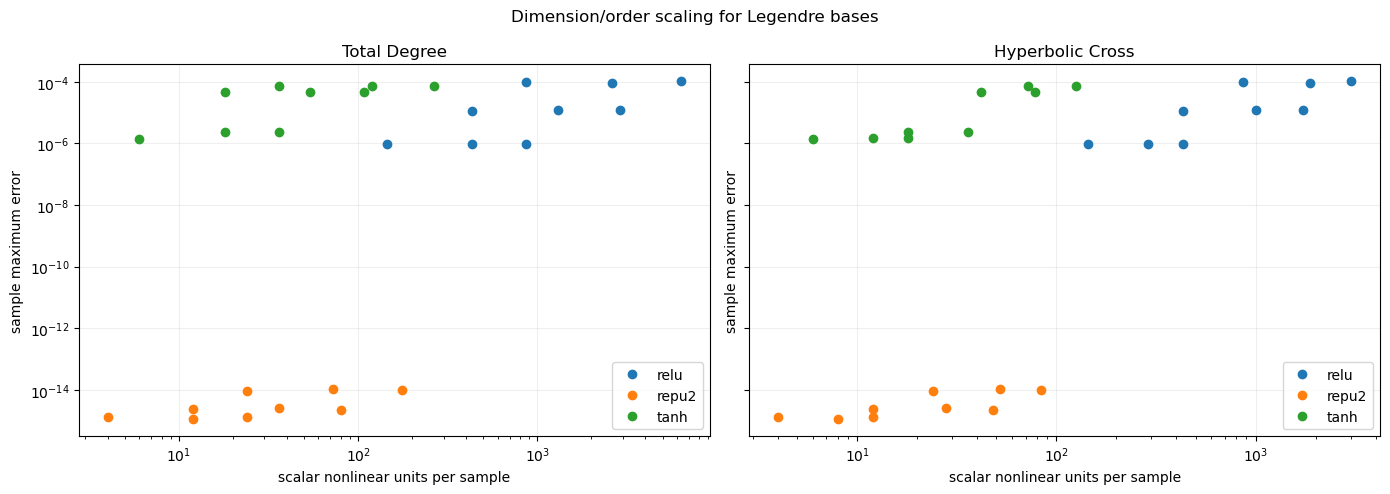

In [9]:
fig, axes = plt.subplots(1, len(SCALING_INDEX_SETS), figsize=(14, 5), sharey=True)
for ax, index_set_type in zip(axes, SCALING_INDEX_SETS):
    subset = scaling_table[scaling_table["index_set"] == index_set_type]
    for product, group in subset.groupby("product"):
        ax.loglog(
            group["activation_units_per_sample"],
            np.maximum(group["sample_max_error"], 1e-18),
            marker="o",
            linestyle="none",
            label=product,
        )
    ax.set(
        xlabel="scalar nonlinear units per sample",
        ylabel="sample maximum error",
        title=index_set_type.replace("_", " ").title(),
    )
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle(f"Dimension/order scaling for {FAMILY.title()} bases")
fig.tight_layout()
plt.show()
